In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
import cv2
import os
import random
from PIL import Image
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv(
    r"C:\Users\ridim\OneDrive\Desktop\landmark_detection\gldv2_micro\train.csv"
)

base_path = r"C:\Users\ridim\OneDrive\Desktop\landmark_detection\gldv2_micro\images"

In [3]:
print(df.head())
print(df.shape)

               filename  landmark_id
0  fd1a404e12754adb.jpg            0
1  f8fc91efb0d408b3.jpg            0
2  f754a84914ad92f3.jpg            0
3  f2fa9bde2d444ede.jpg            0
4  f10af00527cb5f5b.jpg            0
(23294, 2)


In [4]:
df

,filename,landmark_id
0,fd1a404e12754adb.jpg,0
1,f8fc91efb0d408b3.jpg,0
2,f754a84914ad92f3.jpg,0
3,f2fa9bde2d444ede.jpg,0
4,f10af00527cb5f5b.jpg,0
...,...,...
23289,e425afbb75ad4bfb.jpg,3102
23290,d7da2684287d4844.jpg,3102
23291,b80854a231f44e8d.jpg,3102
23292,457cb65ba4a1ee3d.jpg,2029


In [5]:
samples = len(df)
num_classes = df["landmark_id"].nunique()
num_data = len(df)

In [6]:
num_classes

3103

In [7]:
num_data

23294

In [8]:
data = df["landmark_id"].value_counts().reset_index()
data.columns = ["landmark_id", "count"]

data.head()

,landmark_id,count
0,2029,9
1,1039,8
2,1261,8
3,1296,8
4,2459,8


In [9]:
data.tail()

,landmark_id,count
3098,1378,7
3099,1377,7
3100,1376,7
3101,1375,7
3102,3102,7


In [10]:
data['count'].describe()

count    3103.000000
mean        7.506929
std         0.500677
min         7.000000
25%         7.000000
50%         8.000000
75%         8.000000
max         9.000000
Name: count, dtype: float64

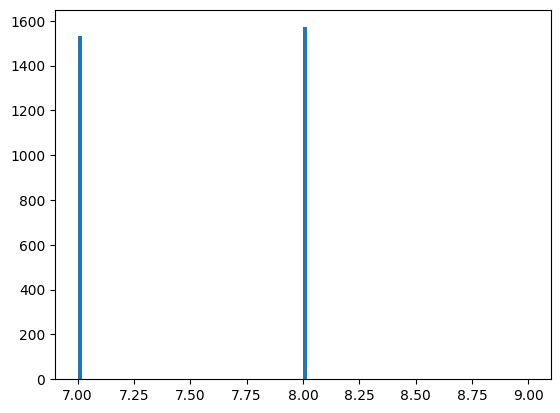

In [11]:
data['count'].describe()

plt.hist(data['count'], bins=100)
plt.show()

In [12]:
data['count'].between(0,5).sum()

0

In [13]:
data['count'].between(5,10).sum()

3103

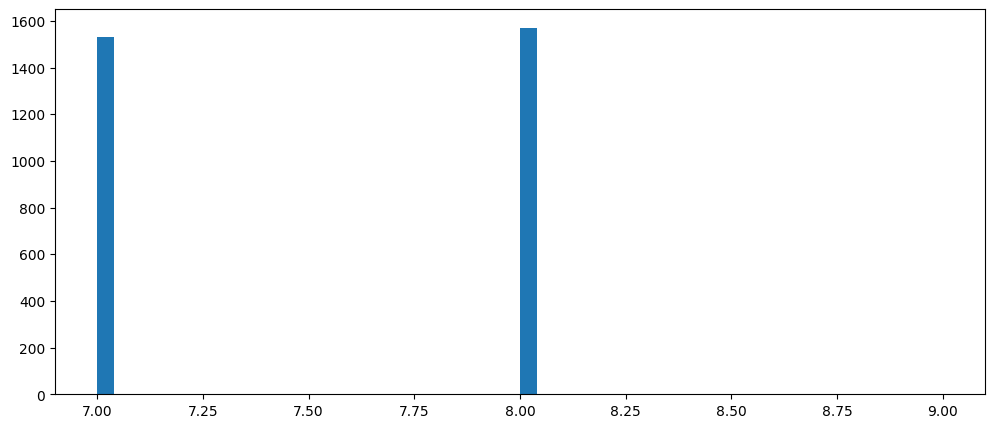

In [14]:
plt.figure(figsize=(12,5))
plt.hist(data['count'], bins=50)
plt.show()

In [15]:
from sklearn.preprocessing import LabelEncoder
lencoder = LabelEncoder()
lencoder.fit(df["landmark_id"])

LabelEncoder()

In [16]:
df.head()

,filename,landmark_id
0,fd1a404e12754adb.jpg,0
1,f8fc91efb0d408b3.jpg,0
2,f754a84914ad92f3.jpg,0
3,f2fa9bde2d444ede.jpg,0
4,f10af00527cb5f5b.jpg,0


In [17]:
def encode_label(lbl):
    return lencoder.transform(lbl)

def decode_label(lbl):
    return lencoder.inverse_transform(lbl)

In [32]:
def get_image_from_number(num, df):
    fname = df.iloc[num]["filename"]
    label = df.iloc[num]["landmark_id"]

    path = os.path.join(base_path, fname)

    img = cv2.imread(path)

    return img, label

4 Sample Images


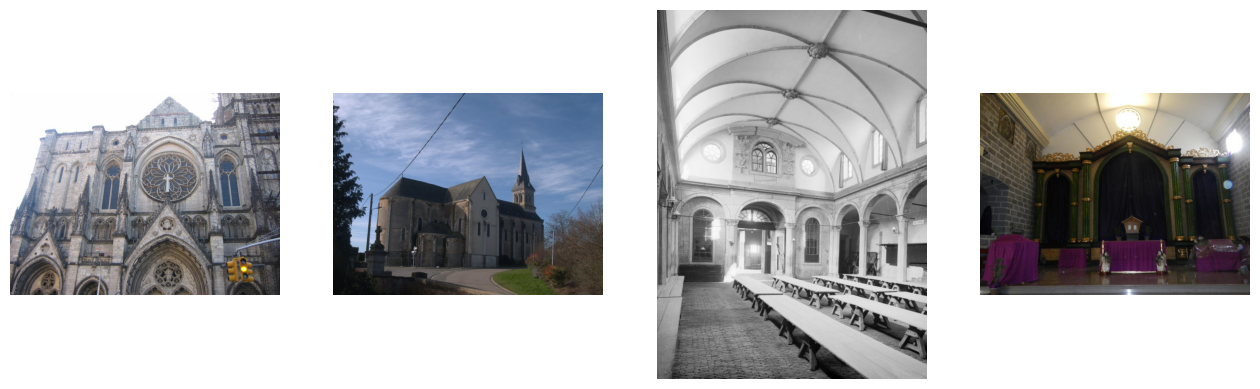

In [19]:
print("4 Sample Images")

fig = plt.figure(figsize=(16,16))

imgs = random.sample(os.listdir(base_path), 4)

for i, img_name in enumerate(imgs, 1):
    img = np.array(Image.open(os.path.join(base_path, img_name)))

    fig.add_subplot(1,4,i)
    plt.imshow(img)
    plt.axis('off')

plt.show()

In [20]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import *
from tensorflow.keras import Sequential

In [21]:
learning_rate = 0.0001
loss_function = "sparse_categorical_crossentropy"

In [22]:
base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dropout(0.5),
    Dense(num_classes, activation="softmax")
])



9406464/9406464 [==============================] - 5s 0us/step


In [23]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
    loss=loss_function,
    metrics=["accuracy"]
)

In [24]:
def image_reshape(im, target_size):
    return cv2.resize(im, target_size)

In [33]:
def get_batch(dataframe, start, batch_size):
    image_array = []
    label_array = []

    end_img = min(start + batch_size, len(dataframe))

    for idx in range(start, end_img):
        im, label = get_image_from_number(idx, dataframe)

        if im is None:
            continue

        im = image_reshape(im, (224, 224)) / 255.0

        image_array.append(im)
        label_array.append(label)

    if len(image_array) == 0:
        return np.array([]), np.array([])

    label_array = encode_label(label_array)

    return np.array(image_array), np.array(label_array)

In [26]:
batch_size = 16
epoch_shuffle = True
weight_classes = True
epochs = 1

train = pd.read_csv(
    r"C:\Users\ridim\OneDrive\Desktop\landmark_detection\gldv2_micro\train.csv"
)

val = pd.read_csv(
    r"C:\Users\ridim\OneDrive\Desktop\landmark_detection\gldv2_micro\val.csv"
)

print(len(train))
print(len(val))

23294
3103


In [27]:
for e in range(epochs):
    print(f"Epoch {e+1}/{epochs}")

    if epoch_shuffle:
        train = train.sample(frac=1).reset_index(drop=True)

    for it in range(int(np.ceil(len(train) / batch_size))):
        x_train, y_train = get_batch(
            train,
            it * batch_size,
            batch_size
        )

        if len(x_train) == 0:
            continue

        model.train_on_batch(x_train, y_train)

model.save("gldv2_micro_vgg19.keras")

Epoch 1/1




In [28]:
batch_size = 16

errors = 0
good_preds = []
bad_preds = []

for it in range(int(np.ceil(len(val) / batch_size))):

    x_val, y_val = get_batch(
        val,
        it * batch_size,
        batch_size
    )

    if len(x_val) == 0:
        continue

    result = model.predict(x_val, verbose=0)
    pred = np.argmax(result, axis=1)

    for idx in range(len(pred)):

        if pred[idx] != y_val[idx]:
            errors += 1
            bad_preds.append([
                batch_size * it + idx,
                pred[idx],
                result[idx][pred[idx]]
            ])
        else:
            good_preds.append([
                batch_size * it + idx,
                pred[idx],
                result[idx][pred[idx]]
            ])

print("Good predictions:", len(good_preds))
print("Bad predictions:", len(bad_preds))

Good predictions: 329
Bad predictions: 2774


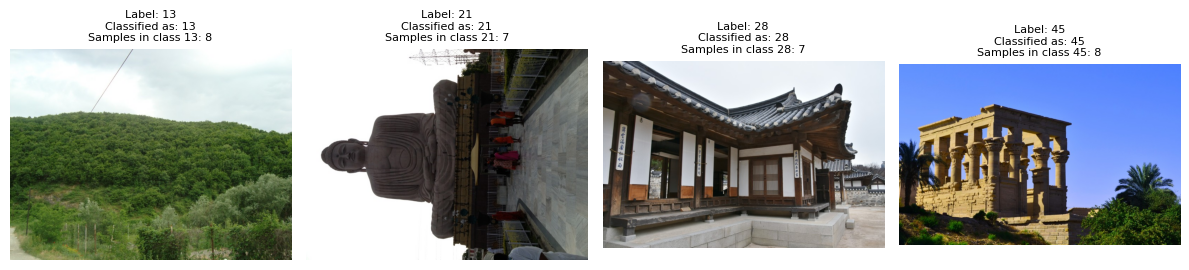

In [35]:
plt.figure(figsize=(12,12))

for i in range(min(4, len(good_preds))):

    n = int(good_preds[i][0])

    img, lbl = get_image_from_number(n, val)

    if img is None:
        continue

    pred = decode_label([good_preds[i][1]])[0]

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(1,4,i+1)
    plt.imshow(img)

    plt.title(
        f"Label: {lbl}\n"
        f"Classified as: {pred}\n"
        f"Samples in class {lbl}: {(train['landmark_id']==lbl).sum()}",
        fontsize=8
    )

    plt.axis("off")

plt.tight_layout()
plt.show()